# Logistic Regression

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## I. Linear Regression & Perceptron Learning Algorithm (PLA)

In [9]:
# Data
hours    = [1.0, 1.2, 1.5, 1.8, 2.0, 2.2, 2.5, 2.8, 3.0, 3.2, 3.5, 3.8, 4.0, 4.2, 4.5, 4.8, 5.0, 5.5, 6.0, 6.5]
outcomes = [0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1]
df = pd.DataFrame({'Hours': hours,
                   'Outcome': outcomes})

df

,Hours,Outcome
0,1.0,0
1,1.2,0
2,1.5,0
3,1.8,0
4,2.0,0
5,2.2,1
6,2.5,0
7,2.8,1
8,3.0,0
9,3.2,1


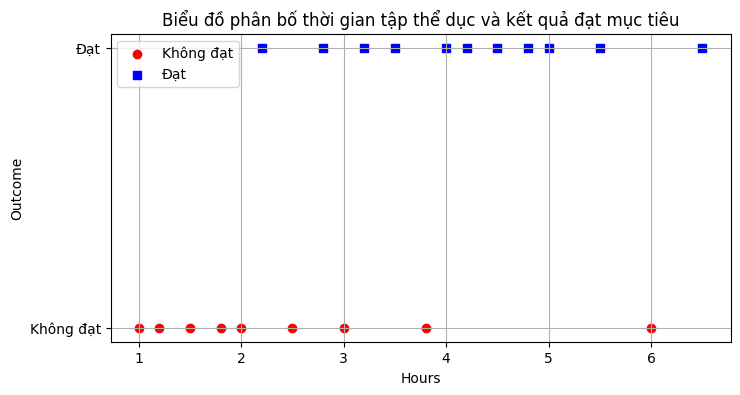

In [5]:
plt.figure(figsize=(8, 4))
plt.scatter(df[df['Outcome']==0]['Hours'], df[df['Outcome']==0]['Outcome'], color='red', marker='o', label='Không đạt')
plt.scatter(df[df['Outcome']==1]['Hours'], df[df['Outcome']==1]['Outcome'], color='blue', marker='s', label='Đạt')
plt.xlabel('Hours')
plt.ylabel('Outcome')
plt.yticks([0, 1], ['Không đạt', 'Đạt'])
plt.title('Biểu đồ phân bố thời gian tập thể dục và kết quả đạt mục tiêu')
plt.legend()
plt.grid(True)
plt.show()

Từ biểu đồ, có thể thấy rằng không thể vẽ một đường thẳng (non-linearly separable) để phân tách hoàn toàn các điểm đỏ (Không đạt) và xanh (Đạt), đặc biệt trong khoảng từ 2.0 đến 4.0 giờ, nơi các kết quả xen kẽ nhau.

# II. Logistic Regression

In [14]:
# Data
X_data = np.array([[0.50, 0.75, 1.00, 1.25, 1.50, 1.75, 1.75, 2.00, 2.25, 2.50, 2.75, 3.00, 3.25, 3.50, 4.00, 4.25, 4.50, 4.75, 5.00, 5.50]])
y_data = np.array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1])

# Add bias (x0 = 1)
X_bar = np.concatenate((np.ones((1, X_data.shape[1])), X_data), axis=0)

In [17]:
def sigmoid(s):
   return 1 / (1 + np.exp(-s))

def logistic_regression(X, y, w_init, eta, tol = 1e-4, max_iter = 10000):
    w  = [w_init]
    iter = 0
    N  = X.shape[1]
    d  = X.shape[0]
    check_w_after = 20

    while iter < max_iter:
        mix_id = np.random.permutation(N)
        for i in mix_id:
            xi = X[:, i].reshape(d, 1)
            yi = y[i]

            # Prediction
            zi = sigmoid(np.dot(w[-1].T, xi))
            # Update w
            w_new = w[-1] + eta * (yi - zi) * xi
            iter += 1

            # Stopping Criteria
            if iter % check_w_after == 0:
                if np.linalg.norm(w_new - w[-1]) < tol:
                    print(f'Converged after {iter} iterations.')
                    return w
                
                w.append(w_new)
            else:
                w[-1] = w_new

            if iter >= max_iter:
                break

    print(f'Reached max iterations ({max_iter}).')
    return w

In [19]:
# Initialization
d = X_bar.shape[0]
w_init = np.random.randn(d, 1)
eta = 0.05

# Training
w_log = logistic_regression(X_bar, y_data, w_init, eta)
w_final = w_log[-1]
print("Weights (w0, w1):", w_final.T)

Reached max iterations (10000).
Weights (w0, w1): [[-4.14519413  1.43713949]]


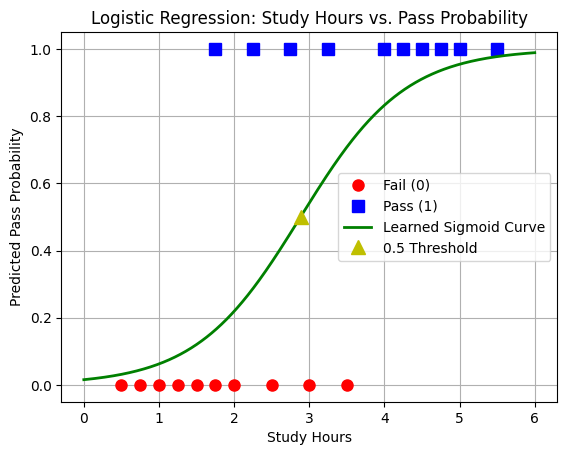

Decision threshold (hours for P=0.5): 2.88


In [20]:
# Visualization
X0 = X_data[0, np.where(y_data == 0)][0]
y0 = y_data[np.where(y_data == 0)]
X1 = X_data[0, np.where(y_data == 1)][0]
y1 = y_data[np.where(y_data == 1)]

plt.plot(X0, y0, 'ro', markersize=8, label='Fail (0)')
plt.plot(X1, y1, 'bs', markersize=8, label='Pass (1)')

xx = np.linspace(0, 6, 1000)
w0 = w_final[0][0]
w1 = w_final[1][0]
yy = sigmoid(w0 + w1 * xx)

plt.plot(xx, yy, 'g-', linewidth=2, label='Learned Sigmoid Curve')

# Threshold
threshold = -w0 / w1
if 0 <= threshold <= 6:
    plt.plot(threshold, 0.5, 'y^', markersize=10, label='0.5 Threshold')

plt.xlabel('Study Hours')
plt.ylabel('Predicted Pass Probability')
plt.title('Logistic Regression: Study Hours vs. Pass Probability')
plt.legend()
plt.grid(True)
plt.show()

print(f"Decision threshold (hours for P=0.5): {threshold:.2f}")

****